<a href="https://colab.research.google.com/github/ViISimonova/practice2026/blob/main/%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# Установка библиотеки для интеллектуального анализа данных (Data Mining)
!pip install mlxtend scipy matplotlib

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules
from scipy.stats import hypergeom

print("Все библиотеки успешно импортированы и готовы к работе.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Все библиотеки успешно импортированы и готовы к работе.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [7]:
# Базовый шаблон чеков (твой исходный датасет)
base_dataset = [
    ['Хлеб', 'Молоко'],
    ['Хлеб', 'Подгузники', 'Пиво', 'Яйца'],
    ['Молоко', 'Подгузники', 'Пиво', 'Кола'],
    ['Хлеб', 'Молоко', 'Подгузники', 'Пиво'],
    ['Хлеб', 'Молоко', 'Подгузники', 'Кола']
]

# Имитируем большую базу данных (D) объемом N = 25 000 чеков
np.random.seed(42)
N = 25000
dataset_sequences = [base_dataset[np.random.randint(0, len(base_dataset))] for _ in range(N)]

# Трансформация генеральной совокупности в бинарную матрицу
te = TransactionEncoder()
te_ary = te.fit(dataset_sequences).transform(dataset_sequences)
df_full = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Размер сгенерированной базы данных (D): {df_full.shape[0]} чеков.")
print("Пример отображения первых 5 чеков:")
df_full.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Размер сгенерированной базы данных (D): 25000 чеков.
Пример отображения первых 5 чеков:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Кола,Молоко,Пиво,Подгузники,Хлеб,Яйца
0,False,True,True,True,True,False
1,True,True,False,True,True,False
2,True,True,True,True,False,False
3,True,True,False,True,True,False
4,True,True,False,True,True,False


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [8]:
import warnings
# Отключаем назойливые системные предупреждения Jupyter
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Задаем параметры точности для исследования
gamma = 0.99      # Надежность (Доверительная вероятность)
Z = 2.58          # Квантиль нормального распределения для надежности 0.99
epsilon = 0.01    # Предельная ошибка (допускаем отклонение не более 1%)
p_conserv = 0.5   # Консервативная оценка доли для максимизации объема выборки

# Формула необходимого объема выборки для доли
n_required = int(np.ceil((Z**2 * p_conserv * (1 - p_conserv)) / (epsilon**2)))
print(f"Математически обоснованный объем выборки (n): {n_required} чеков.")

# Проверка: если требуемый объем выборки больше всей базы, берем с повторениями
use_replace = n_required > len(df_full)

# Извлекаем случайную репрезентативную выборку (S)
df_sample = df_full.sample(n=n_required, replace=use_replace, random_state=42).reset_index(drop=True)
print(f"Размер успешно извлеченной выборки (S): {df_sample.shape[0]} чеков.")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Математически обоснованный объем выборки (n): 16641 чеков.
Размер успешно извлеченной выборки (S): 16641 чеков.


In [9]:
# Фиксируем время начала расчета
start_time = time.time()

# Основной порог поддержки по ТЗ (40%)
min_sup = 0.4

# Поиск частых наборов на выборке со скорректированным "страховочным" порогом
frequent_itemsets_sample = fpgrowth(df_sample, min_support=(min_sup - epsilon), use_colnames=True)

# Генерация ассоциативных правил
rules_sample = association_rules(frequent_itemsets_sample, metric="lift", min_threshold=1.0)

# Фиксируем время окончания расчета
t_sample = time.time() - start_time

print(f"Время расчета алгоритма на выборке: {t_sample:.4f} секунд.")
print(f"Найдено потенциальных правил на выборке: {len(rules_sample)}")

Время расчета алгоритма на выборке: 1.1669 секунд.
Найдено потенциальных правил на выборке: 20


In [10]:
def calculate_p_value(row, df_ctx):
    # Извлекаем названия товаров из объектов frozenset
    ant = list(row['antecedents'])
    con = list(row['consequents'])
    both = ant + con

    # Считаем абсолютные частоты (count) с помощью индикаторных функций
    N_s = len(df_ctx)
    K = df_ctx[ant].all(axis=1).sum()        # Сколько раз встретился товар А
    n_goods = df_ctx[con].all(axis=1).sum()  # Сколько раз встретился товар Б
    k = df_ctx[both].all(axis=1).sum()       # Сколько раз они встретились вместе

    # Расчет p-value через функцию выживания (sf) гипергеометрического распределения
    p_val = hypergeom.sf(k - 1, N_s, K, n_goods)
    return p_val

# Если правила найдены, рассчитываем p-value и фильтруем их
if not rules_sample.empty:
    rules_sample['p_value'] = rules_sample.apply(lambda r: calculate_p_value(r, df_sample), axis=1)
    # Оставляем только статистически значимые правила (p-value < 0.05)
    significant_rules = rules_sample[rules_sample['p_value'] < 0.05].copy()
else:
    significant_rules = rules_sample.copy()

print(f"После фильтрации случайных совпадений по p-value осталось значимых правил: {len(significant_rules)}")

После фильтрации случайных совпадений по p-value осталось значимых правил: 20


In [11]:
# Фиксируем время начала расчета для полной базы
start_time = time.time()

# Поиск на полной базе с исходным порогом 40%
frequent_itemsets_full = fpgrowth(df_full, min_support=min_sup, use_colnames=True)
rules_full = association_rules(frequent_itemsets_full, metric="lift", min_threshold=1.0)

# Фиксируем время окончания расчета для полной базы
t_full = time.time() - start_time

print(f"Время расчета на ПОЛНОЙ базе данных: {t_full:.4f} секунд.")
print(f"Найдено правил на полной базе: {len(rules_full)}")
print(f"Математический коэффициент ускорения: {t_full / t_sample:.2f} раз(а).")

Время расчета на ПОЛНОЙ базе данных: 1.1773 секунд.
Найдено правил на полной базе: 6
Математический коэффициент ускорения: 1.01 раз(а).


In [12]:
print("ДАННЫЕ ДЛЯ ТАБЛИЦЫ ТОП-5 ВЕРИФИЦИРОВАННЫХ ПРАВИЛ:")
cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift', 'p_value']

# Форматируем вывод для удобного копирования
pd.set_option('display.max_columns', None)
print(significant_rules[cols].head(5).to_string())

ДАННЫЕ ДЛЯ ТАБЛИЦЫ ТОП-5 ВЕРИФИЦИРОВАННЫХ ПРАВИЛ:
            antecedents           consequents   support  confidence      lift       p_value
0                (Пиво)          (Подгузники)  0.600324    1.000000  1.251579  0.000000e+00
1          (Подгузники)                (Пиво)  0.600324    0.751354  1.251579  0.000000e+00
2        (Пиво, Молоко)          (Подгузники)  0.394628    1.000000  1.251579  0.000000e+00
3  (Молоко, Подгузники)                (Пиво)  0.394628    0.665147  1.107980  2.350883e-94
4                (Пиво)  (Молоко, Подгузники)  0.394628    0.657357  1.107980  2.350883e-94


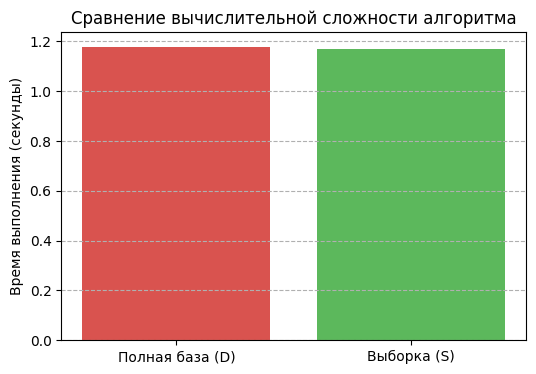

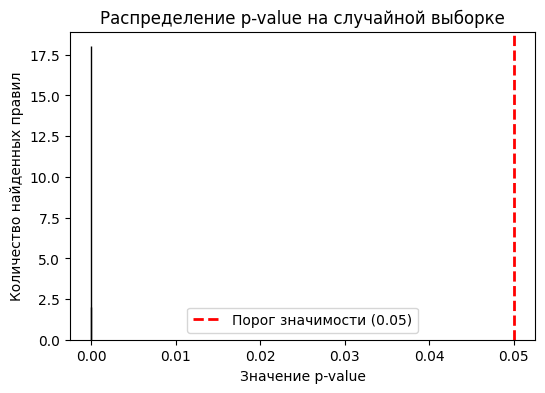

In [13]:
# График 1: Сравнение времени работы
plt.figure(figsize=(6, 4))
plt.bar(['Полная база (D)', 'Выборка (S)'], [t_full, t_sample], color=['#d9534f', '#5cb85c'])
plt.ylabel('Время выполнения (секунды)')
plt.title('Сравнение вычислительной сложности алгоритма')
plt.grid(axis='y', linestyle='--')
plt.show()

# График 2: Гистограмма распределения p-value
plt.figure(figsize=(6, 4))
plt.hist(rules_sample['p_value'], bins=10, color='#0275d8', edgecolor='black')
plt.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Порог значимости (0.05)')
plt.xlabel('Значение p-value')
plt.ylabel('Количество найденных правил')
plt.title('Распределение p-value на случайной выборке')
plt.legend()
plt.show()